1. What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.
- a data analysis technique used to identify rare, unexpected events, observations, or patterns that deviate significantly from the majority of data, often signaling issues like fraud, system malfunctions, or security breaches.

2. Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of
their approach and suitable use cases.
- Isolation Forest, DBSCAN, and Local Outlier Factor (LOF) are popular unsupervised anomaly detection methods with distinct approaches: Isolation Forest isolates anomalies using trees, DBSCAN detects noise in low-density, arbitrary-shaped clusters, and LOF identifies outliers based on local, relative density.

3. What are the key components of a Time Series? Explain each with one
example.
- The key components of a time series are Trend, Seasonality, Cyclical, and Irregular/Residual patterns.

4. Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one?
- A stationary time series has statistical properties—mean, variance, and autocorrelation—that remain constant over time, making it predictable for modeling.

5. Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.
-

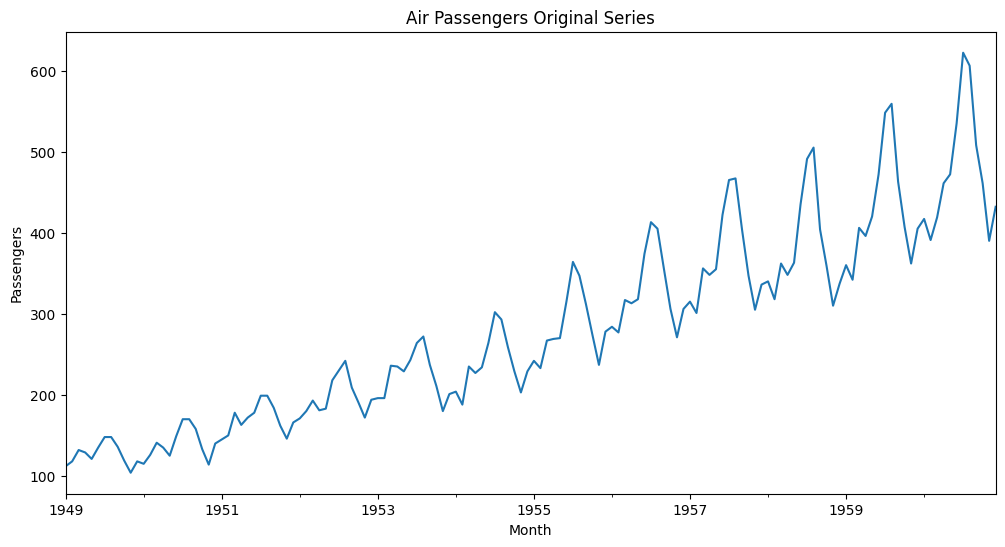

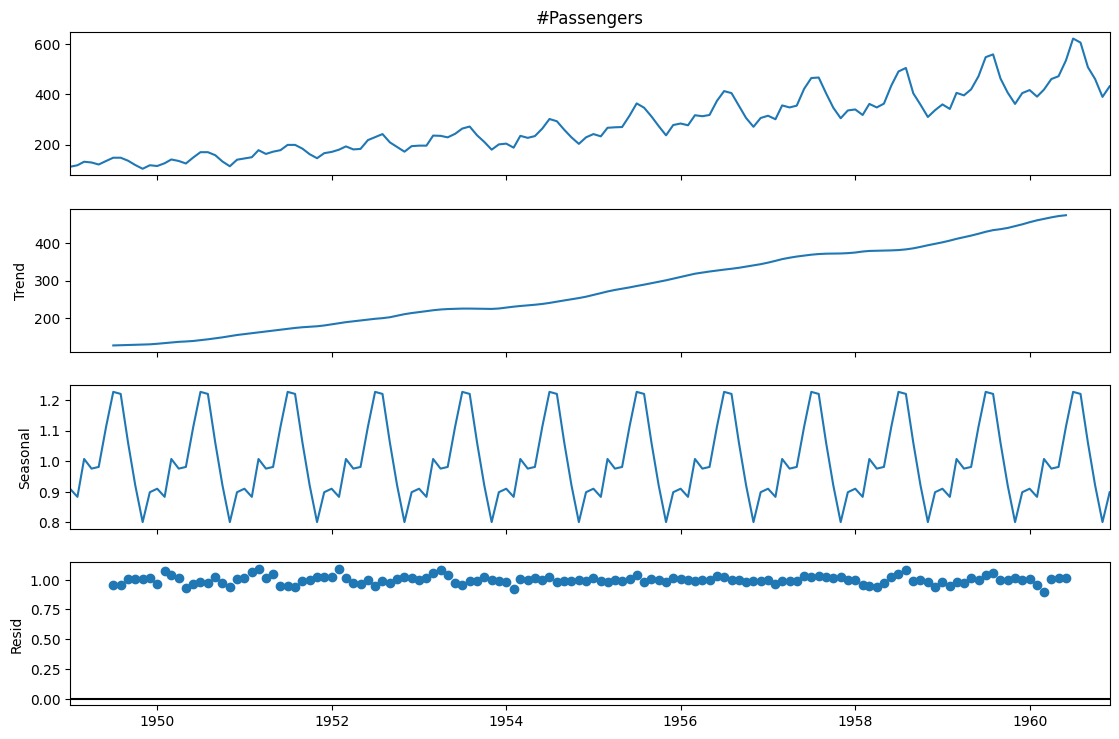

In [ ]:
#6. Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components


import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Correcting the URL to a direct download link for Google Drive
file_id = '1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3'
url = f'https://drive.google.com/uc?id={file_id}'

# Reading the dataset
airpass = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Note: The column name in this specific CSV is '#Passengers'
column_name = '#Passengers'

airpass[column_name].plot(figsize=(12, 6), title='Air Passengers Original Series')
plt.ylabel('Passengers')
plt.show()

# Decomposing the time series using the correct column name
result = seasonal_decompose(airpass[column_name], model='multiplicative', period=12)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

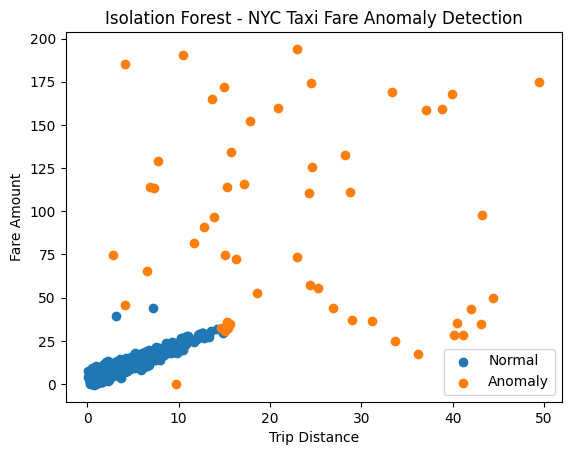

53

In [ ]:
#7. Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
np.random.seed(42)

n_normal = 1000
trip_distance = np.random.gamma(shape=2., scale=2., size=n_normal)
fare_amount = 2.5 + 2.0 * trip_distance + np.random.normal(0, 2, n_normal)

n_anomalies = 50
trip_distance_anom = np.random.uniform(0, 50, n_anomalies)
fare_amount_anom = np.random.uniform(0, 200, n_anomalies)

trip_distance_all = np.concatenate([trip_distance, trip_distance_anom])
fare_amount_all = np.concatenate([fare_amount, fare_amount_anom])

data = pd.DataFrame({
    "trip_distance": trip_distance_all,
    "fare_amount": fare_amount_all
})

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

iso_forest = IsolationForest(contamination=0.05, random_state=42)
data['anomaly'] = iso_forest.fit_predict(scaled_data)

normal_data = data[data['anomaly'] == 1]
anomaly_data = data[data['anomaly'] == -1]

plt.figure()
plt.scatter(normal_data["trip_distance"], normal_data["fare_amount"], label="Normal")
plt.scatter(anomaly_data["trip_distance"], anomaly_data["fare_amount"], label="Anomaly")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Isolation Forest - NYC Taxi Fare Anomaly Detection")
plt.legend()
plt.show()

len(anomaly_data)


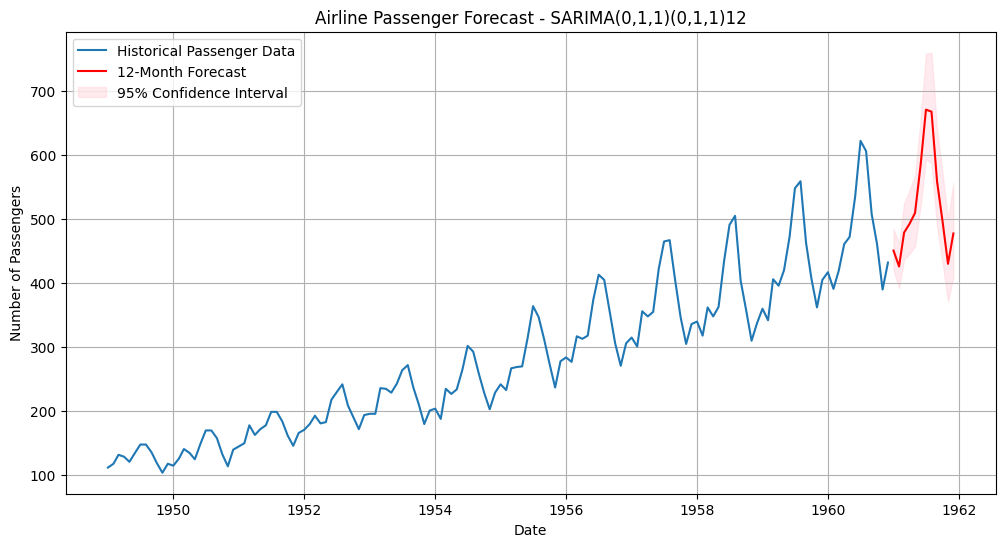

In [ ]:
#8. Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Using the 'airpass' variable loaded in cell #6 instead of reading from a missing file
data = airpass.copy()
data.index.freq = 'MS'

# The column name in the airpass DataFrame is '#Passengers'
target_col = '#Passengers'
data[target_col] = data[target_col].astype(float)
data['log_passengers'] = np.log(data[target_col])

model = SARIMAX(data['log_passengers'],
                order=(0, 1, 1),
                seasonal_order=(0, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
results = model.fit()

n_forecast = 12
forecast_res = results.get_forecast(steps=n_forecast)
forecast_mean = forecast_res.predicted_mean
conf_int = forecast_res.conf_int()

forecast_values = np.exp(forecast_mean)
conf_int_values = np.exp(conf_int)

plt.figure(figsize=(12, 6))
plt.plot(data[target_col], label='Historical Passenger Data')
plt.plot(forecast_values, label='12-Month Forecast', color='red')
plt.fill_between(conf_int_values.index,
                 conf_int_values.iloc[:, 0],
                 conf_int_values.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title('Airline Passenger Forecast - SARIMA(0,1,1)(0,1,1)12')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

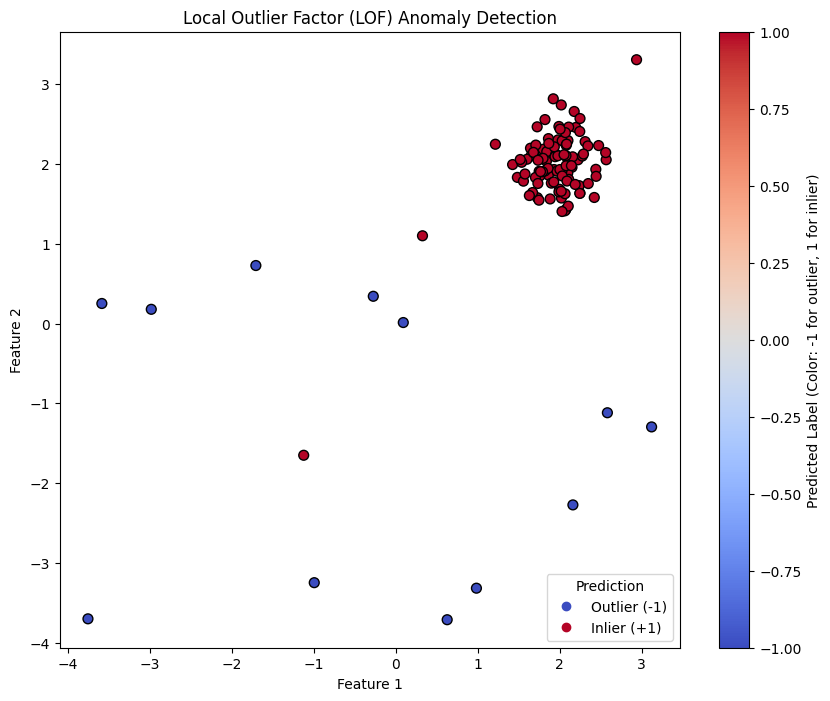

In [ ]:
#9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = X_inliers + 2

X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X_outliers = X_outliers[np.linalg.norm(X_outliers - 2, axis=1) > 1.5]
X = np.concatenate([X_inliers, X_outliers], axis=0)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

y_pred = lof.fit_predict(X)

scores = lof.negative_outlier_factor_ * -1

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='coolwarm', s=50, edgecolors='k')
plt.title("Local Outlier Factor (LOF) Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

legend = scatter.legend_elements()
plt.legend(handles=legend[0], labels=['Outlier (-1)', 'Inlier (+1)'], loc="lower right", title="Prediction")

plt.colorbar(label='Predicted Label (Color: -1 for outlier, 1 for inlier)')

plt.show()


In [ ]:
#10. You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.

